In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# Teacher targets on the states the student visits

Day 26 · Chapter 15 · selected extension · CPU-only finite teacher and actual neural student.

When a student emits a wrong first token, should its next training signal be evaluated on the correct teacher prefix or on its own wrong prefix? Separately, should we minimize KL(teacher‖student) or KL(student‖teacher)? Predict before running: these are different choices. Student-collected states do not force a KL direction or guarantee an improvement.

Our original task reverses two symbolic letters. The student is a real 2,864-parameter causal decoder. The teacher is an explicitly authored finite policy, not a neural/pretrained model or an authentic self-teacher. An authored answer hint can change only the teacher’s training targets. No hint enters student inputs or evaluation generation. This is not full SDPO or the full derivative through a policy’s state distribution.

The historical campaign remains unchanged. A separately specified hardening follow-up rejects zero-support conditional-tail detail and mixed collection cohorts. The setup verifies exact original source snapshots, and the fresh replays below use the hardened API without changing the recipe or selecting better outcomes.

Saved reference preview from fresh CPU execution, not a live plot or upstream result. Rerun the adjacent cells to regenerate figures.

![Question-only student states and private teacher targets](../figures/chapter-15/day-26-05_student_prefix_and_teacher_context-01.png)

In [2]:
from pathlib import Path
import sys,json,hashlib
from copy import deepcopy
root=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"src/dongxi_llms").is_dir())
if str(root/"src") not in sys.path:sys.path.insert(0,str(root/"src"))
import torch,numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from dongxi_llms.student_prefix_lab import (A,B,C,EOS,VOCAB,SEEDS,aligned_kl,collect_attempt,
    distribution_controls,fit_arm,freeze_contract,kl_probabilities,make_student,question,
    score_states,state_digest,teacher_distribution,topk_tail,validate_contract,validate_fixture)
torch.set_num_threads(1)
plt.rcParams.update({"font.family":"DejaVu Sans","font.size":10,
    "axes.spines.top":False,"axes.spines.right":False,"figure.figsize":(10,4)})
fixture=json.loads((root/"fixtures/student-prefix/items.json").read_text());items=fixture["items"]
directory=root/"experiments/reports/2026-10-04-student-prefix-distillation"
raw=(directory/"results.json").read_bytes()
assert hashlib.sha256(raw).hexdigest()=="56ee9b50a319028716b395cf56d4130ced4377b3068c5418aa1124b414258f39"
measured=json.loads(raw);campaigns=measured["campaigns"]
contract=json.loads((directory/"contract.json").read_text());validate_fixture(fixture);validate_contract(contract,fixture)
historical={"student_prefix_lab.py":"original-student_prefix_lab.py.txt",
            "test_student_prefix_lab.py":"original-test_student_prefix_lab.py.txt"}
for path,digest in measured["source_input_sha256"].items():
    p=Path(path);p=p if p.is_absolute() else root/p
    if p.name in historical:
        p=root/"experiments/reports/2026-10-04-student-prefix-hardening"/historical[p.name]
    assert hashlib.sha256(p.read_bytes()).hexdigest()==digest,p
print("Historical measurement source snapshots are intact; current API hardening is a separate intervention.")
colors={"offline":"#326b9e","student-prefix":"#c77743","hint":"#518364","no-hint":"#858585"}
print("Three fixed campaigns, all eight arms, source-bound actual CPU evidence.")


Historical measurement source snapshots are intact; current API hardening is a separate intervention.
Three fixed campaigns, all eight arms, source-bound actual CPU evidence.


## 1. Which information belongs to which model?

Exercise: draw the student’s input when the question is `A B` and it has generated `C`. May we append the correct answer `B A` during evaluation?

Reference: the input is `BOS REVERSE A B C`, even though C is wrong. Only the training teacher may see the separately recorded hint. Independent evaluation generates from the question alone, then a scorer checks the output. A sampled HINT token is an invalid ordinary output, not access to the private answer.

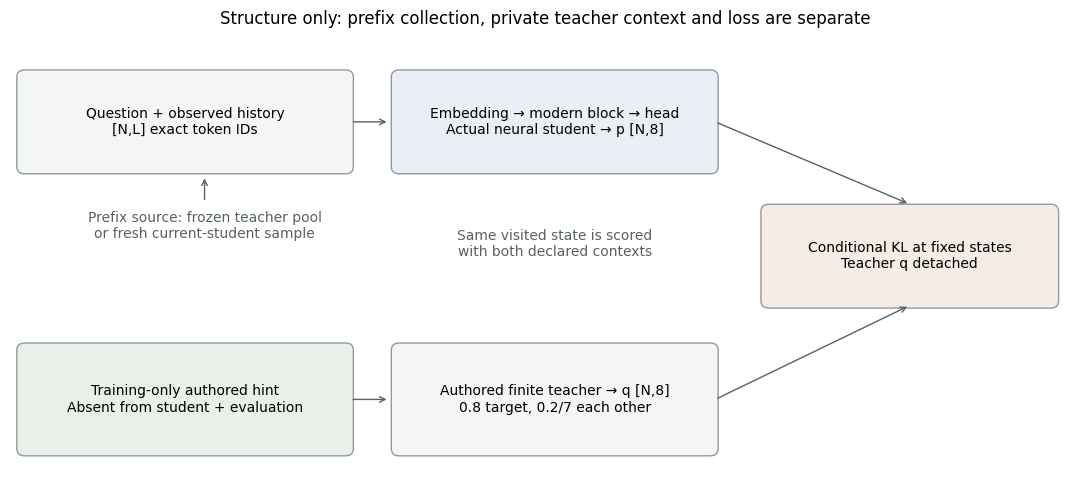

In [3]:
fig,ax=plt.subplots(figsize=(11,5))
ax.set(xlim=(0,11),ylim=(0,5));ax.axis("off")
def box(x,y,w,h,text,color="#f3f5f6"):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=.08",facecolor=color,edgecolor="#939a9e"))
    ax.text(x+w/2,y+h/2,text,ha="center",va="center",fontsize=10)
def arrow(start,end):ax.annotate("",xy=end,xytext=start,arrowprops={"arrowstyle":"->","color":"#566168"})
box(.15,3.5,3.3,1.0,"Question + observed history\n[N,L] exact token IDs")
box(4.0,3.5,3.2,1.0,"Embedding → modern block → head\nActual neural student → p [N,8]","#e9eff5")
box(7.8,2.0,2.9,1.0,"Conditional KL at fixed states\nTeacher q detached","#f4ece5")
box(.15,.35,3.3,1.1,"Training-only authored hint\nAbsent from student + evaluation","#e9f0ea")
box(4.0,.35,3.2,1.1,"Authored finite teacher → q [N,8]\n0.8 target, 0.2/7 each other")
arrow((3.5,4.0),(3.9,4.0));arrow((7.25,4.0),(9.25,3.08))
arrow((3.5,.9),(3.9,.9));arrow((7.25,.9),(9.25,1.95))
ax.text(2.0,2.7,"Prefix source: frozen teacher pool\nor fresh current-student sample",ha="center",color="#566168")
arrow((2.0,3.1),(2.0,3.4))
ax.text(5.6,2.5,"Same visited state is scored\nwith both declared contexts",ha="center",color="#566168")
ax.set_title("Structure only: prefix collection, private teacher context and loss are separate")
plt.tight_layout();plt.show()


## 2. A fresh fixed-seed prefix intervention

Exercise: should offline and student-prefix arms be compared by optimizer updates alone? What happens to their number of states when the student stops early?

Reference: early EOS supplies the state that sampled EOS, but no post-EOS states. Caps retain only states actually visited; they do not invent an EOS. Global valid-state means therefore have different denominators and collection costs. The replay below uses the predeclared recipe, not held-out tuning.

![Observed wrong-prefix state fractions](../figures/chapter-15/day-26-05_student_prefix_and_teacher_context-02.png)

offline fresh30-update checkpoint matches; observed states: 2130


student-prefix fresh30-update checkpoint matches; observed states: 1846


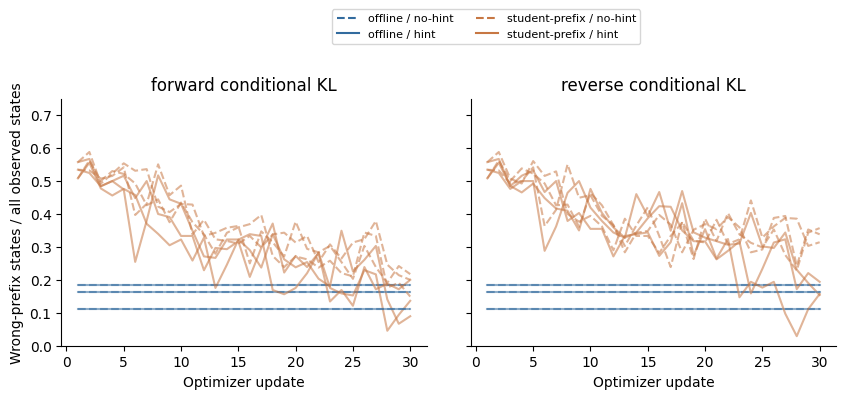

In [4]:
campaign=campaigns[0];initial=make_student(SEEDS[0])
offline=[collect_attempt(None,i,contract,campaign=SEEDS[0],phase="offline",update=0,ordinal=o,arm="finite-offline")
         for i in items if i["split"]=="train" for o in range(4)]
assert [r["token_ids"] for r in offline]==[r["token_ids"] for r in campaign["offline_records"]]
for source in ("offline","student-prefix"):
    model,fit=fit_arm(initial,items,contract,offline,campaign=SEEDS[0],
                      source=source,direction="forward",context="hint")
    stored=next(a for a in campaign["arms"] if a["arm"]==source+"/forward/hint")
    assert fit["initial_state_sha256"]==stored["initial_state_sha256"]
    assert fit["final_state_sha256"]==stored["final_state_sha256"]
    assert [h["state_count"] for h in fit["history"]]==[h["state_count"] for h in stored["history"]]
    print(source,"fresh30-update checkpoint matches; observed states:",
          sum(h["state_count"] for h in fit["history"]))
fig,axes=plt.subplots(1,2,figsize=(10,3.8),sharey=True)
for ax,direction in zip(axes,("forward","reverse")):
    for c in campaigns:
        for source in ("offline","student-prefix"):
            for context in ("no-hint","hint"):
                arm=next(a for a in c["arms"] if (a["source"],a["direction"],a["context"])==(source,direction,context))
                ax.plot([h["update"] for h in arm["history"]],
                        [h["wrong_prefix_states"]/h["state_count"] for h in arm["history"]],
                        color=colors[source],linestyle="-" if context=="hint" else "--",alpha=.55)
    ax.set(title=direction+" conditional KL",xlabel="Optimizer update",ylim=(0,.75))
axes[0].set_ylabel("Wrong-prefix states / all observed states")
from matplotlib.lines import Line2D
handles=[Line2D([0],[0],color=colors[s],linestyle="-" if h=="hint" else "--",label=s+" / "+h)
         for s in ("offline","student-prefix") for h in ("no-hint","hint")]
fig.legend(handles=handles,ncol=2,loc="upper center",bbox_to_anchor=(.55,1.04),fontsize=8)
fig.subplots_adjust(top=.79,bottom=.14,wspace=.12);plt.show()


Reference: solid lines have hints in teacher targets; dashed lines do not. Every seed is plotted. A wrong-prefix state is a property of the observed history, not a label that the loss ignores. The authored no-hint teacher has a deliberately specified recovery failure, so its behavior cannot stand in for a real teacher’s ability.

## 3. Hold the state fixed before changing KL direction

At the same observed state $s$, use forward $D_{KL}(q_s\|p_\theta)$ or reverse $D_{KL}(p_\theta\|q_s)$. Teacher targets are detached in both. Their student-logit gradients differ:

$$
\nabla_z D_{KL}(q\|p)=p-q,
\qquad
\frac{\partial D_{KL}(p\|q)}{\partial z_i}
=p_i\left(\log\frac{p_i}{q_i}-\sum_jp_j\log\frac{p_j}{q_j}\right).
$$

Exercise: if we change the prefix sampler and the divergence together, can we attribute the result to either one? Why does the finite hint change q at a wrong-prefix state but not at a clean one?

Reference: the two factors must be controlled independently. This calculation holds the prefix fixed and shows only conditional-loss gradients. Our sampled-state updates do not differentiate the student’s occupancy distribution and do not include a REINFORCE term.

![Fixed-state teacher distributions and conditional gradients](../figures/chapter-15/day-26-05_student_prefix_and_teacher_context-03.png)

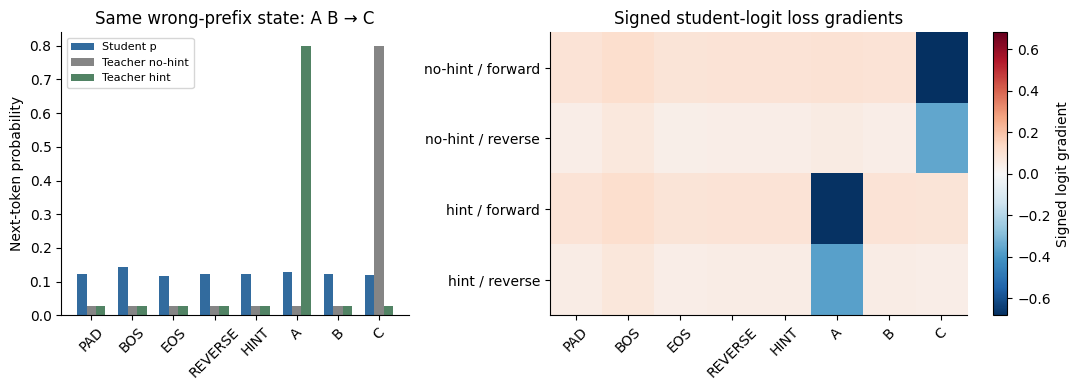

In [5]:
wrong_state=question(next(i for i in items if i["symbols"]==["A","B"]))+[C]
model=make_student(SEEDS[0]);z=model(torch.tensor([wrong_state]))[0,-1].detach().requires_grad_()
q_plain=teacher_distribution([A,B],[C]).requires_grad_()
q_hint=teacher_distribution([A,B],[C],hint=[B,A]).requires_grad_()
gradients=[];row_names=[]
for context,q in (("no-hint",q_plain),("hint",q_hint)):
    for direction in ("forward","reverse"):
        loss=aligned_kl(z,q,direction);g=torch.autograd.grad(loss,z,retain_graph=True)[0]
        assert torch.autograd.grad(loss,q,allow_unused=True,retain_graph=True)[0] is None
        gradients.append(g.tolist());row_names.append(context+" / "+direction)
fig,(left,right)=plt.subplots(1,2,figsize=(11,4),gridspec_kw={"width_ratios":[1,1.5]})
x=np.arange(8)
left.bar(x-.23,z.detach().softmax(-1).numpy(),.23,label="Student p",color="#326b9e")
left.bar(x,q_plain.detach().numpy(),.23,label="Teacher no-hint",color="#858585")
left.bar(x+.23,q_hint.detach().numpy(),.23,label="Teacher hint",color="#518364")
left.set(xticks=x,xticklabels=list(VOCAB),ylabel="Next-token probability",title="Same wrong-prefix state: A B → C")
left.tick_params(axis="x",labelrotation=45);left.legend(fontsize=8)
g=np.array(gradients);limit=abs(g).max()
im=right.imshow(g,vmin=-limit,vmax=limit,cmap="RdBu_r",aspect="auto")
right.set(xticks=x,xticklabels=list(VOCAB),yticks=range(4),yticklabels=row_names,title="Signed student-logit loss gradients")
right.tick_params(axis="x",labelrotation=45)
fig.colorbar(im,ax=right,label="Signed logit gradient")
plt.tight_layout();plt.show()


## 4. Optimization observations are not a task guarantee

Predict: could conditional KL fall while whole-response correctness stays near zero? Are forward and reverse loss values directly comparable?

Reference: the losses summarize different divergence geometries and different visited-state distributions. Compare task behavior on the same independent contract. A shorter trajectory can also reduce collected state exposure; the report retains those denominators.

![Actual conditional KL histories](../figures/chapter-15/day-26-05_student_prefix_and_teacher_context-04.png)

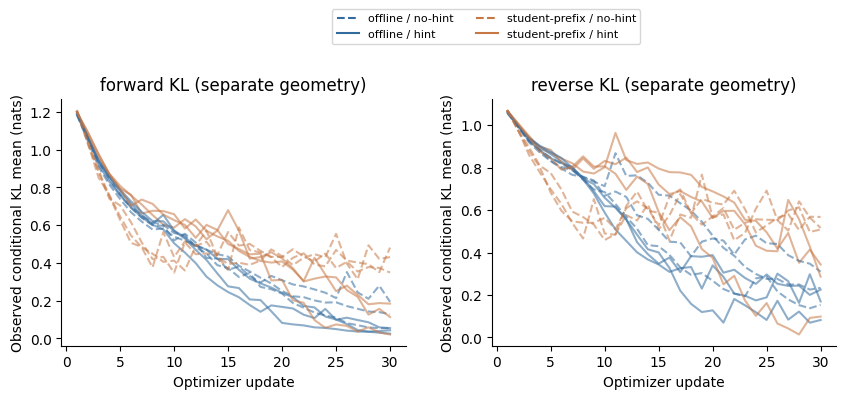

In [6]:
fig,axes=plt.subplots(1,2,figsize=(10,3.8),sharex=True)
for ax,direction in zip(axes,("forward","reverse")):
    for c in campaigns:
        for arm in c["arms"]:
            if arm["direction"]!=direction:continue
            ax.plot([h["update"] for h in arm["history"]],[h["loss"] for h in arm["history"]],
                    color=colors[arm["source"]],linestyle="-" if arm["context"]=="hint" else "--",alpha=.55)
    ax.set(title=direction+" KL (separate geometry)",xlabel="Optimizer update",ylabel="Observed conditional KL mean (nats)")
fig.legend(handles=handles,ncol=2,loc="upper center",bbox_to_anchor=(.55,1.04),fontsize=8)
fig.subplots_adjust(top=.79,bottom=.14,wspace=.25);plt.show()


## 5. No privileged hint at evaluation

Exercise: is a correct final symbol sufficient if the first symbol is wrong? Could a lower training loss establish successful unseen-pair reversal?

Reference: all evaluation responses are generated from the question alone. Whole-response success requires both reversed letters and natural EOS. Final-symbol correctness and format are distinct diagnostics. Three held-out source groups with eight draws each give only24 attempts/arm/seed; this is not a broad reasoning benchmark.

![Question-only held-out generation outcomes](../figures/chapter-15/day-26-05_student_prefix_and_teacher_context-05.png)

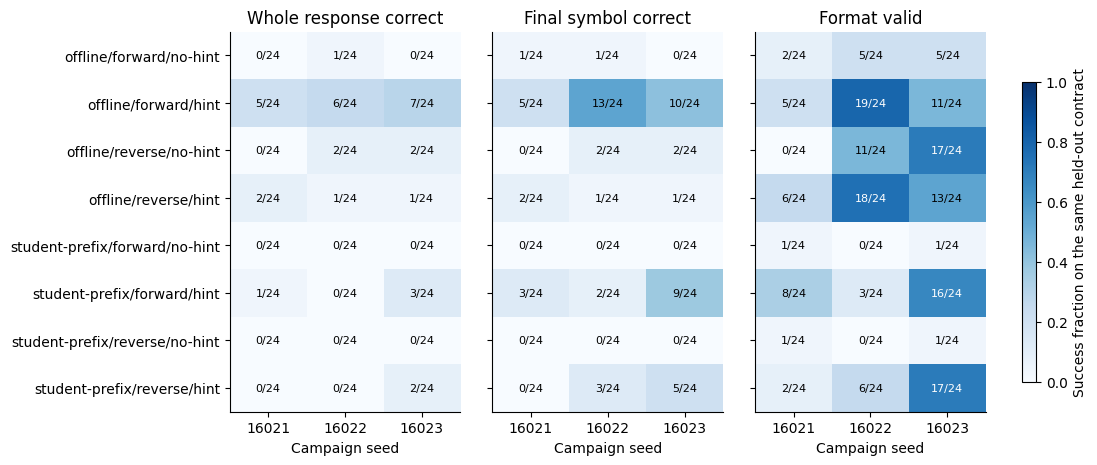

In [7]:
arm_names=[a["arm"] for a in campaigns[0]["arms"]]
fig,axes=plt.subplots(1,3,figsize=(12,5),sharey=True)
for ax,key,title in zip(axes,("correct","final_symbol_correct","format_valid"),
                       ("Whole response correct","Final symbol correct","Format valid")):
    values=np.array([[next(e[key] for e in next(a for a in c["arms"] if a["arm"]==name)["evaluation"]["summary"]
                          if e["split"]=="test") for c in campaigns] for name in arm_names])
    im=ax.imshow(values,vmin=0,vmax=1,cmap="Blues",aspect="auto")
    for y,x in np.ndindex(values.shape):
        ax.text(x,y,f"{round(values[y,x]*24)}/24",ha="center",va="center",
                fontsize=8,color="white" if values[y,x]>.6 else "black")
    ax.set(xticks=range(3),xticklabels=[str(c["seed"]) for c in campaigns],yticks=range(8),yticklabels=arm_names,
           title=title,xlabel="Campaign seed")
fig.subplots_adjust(left=.25,right=.88,bottom=.12,top=.88,wspace=.14)
cax=fig.add_axes([.91,.18,.012,.6]);fig.colorbar(im,cax=cax,label="Success fraction on the same held-out contract")
plt.show()
assert all(a["evaluation"]["teacher_queries"]==0 and not a["evaluation"]["privileged_teacher_context"]
           for c in campaigns for a in c["arms"])


In these frozen tiny runs, changing to student-generated prefixes does not reliably improve the held-out task. The authored teacher’s hint changes its recovery targets, but many hint-trained arms still fail unseen pairs. Every arm/seed/cap stays in the report; do not select a favorable one as a general result.

## 6. A tail bucket retains mass but loses detail

For a fixed top-k set S, retain each selected token plus tail masses $p_{tail}=\sum_{i\notin S}p_i$ and $q_{tail}=\sum_{i\notin S}q_i$. The exact decomposition is

$$
D_{KL}(q\|p)=D_{KL}(q_{bucket}\|p_{bucket})
+q_{tail}D_{KL}(q_{\mathrm{inside}}\|p_{\mathrm{inside}}).
$$

Here $q_{\mathrm{inside}}$ and $p_{\mathrm{inside}}$ are the normalized distributions over unselected tail tokens. The reverse direction weights this conditional detail by $p_{tail}$ instead. Exercise: if selected probabilities and total tail mass agree, must full KL be zero? This detail API requires strictly positive full distributions; zero-support controls use full KL separately.

Reference: no. The explicitly authored control below has identical top-two probabilities and a 0.4 tail for both distributions, but redistributes probability among tail tokens. The bucket loss is exactly 0; the full loss is positive. Selected indices come from detached student ranking, and all discarded token mass remains in the bucket. These are exact finite controls, not measured pretrained approximation errors.

![Full distributions and exact top-k-plus-tail information loss](../figures/chapter-15/day-26-05_student_prefix_and_teacher_context-06.png)

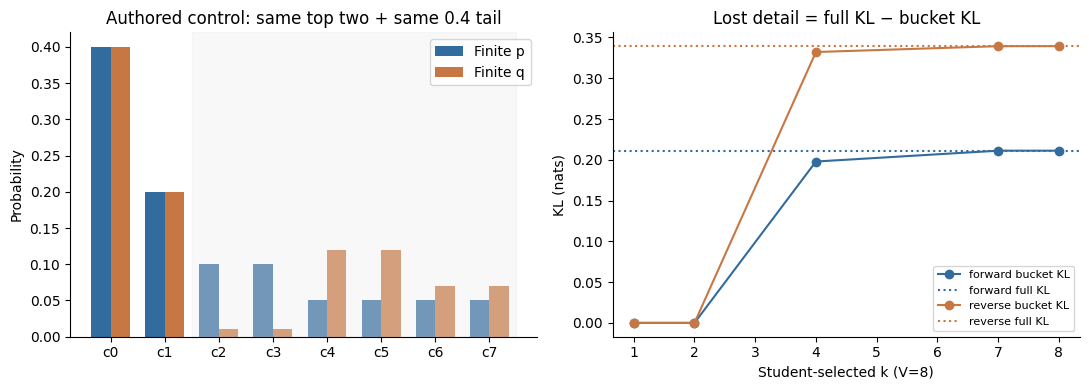

Full KL: 0.21116690823202483 bucket: -8.881784197001253e-17 largest full/bucket logit-gradient difference: 0.09000000000000001


In [8]:
p=torch.tensor(fixture["tail_control"]["p"],dtype=torch.float64)
q=torch.tensor(fixture["tail_control"]["q"],dtype=torch.float64)
fig,(left,right)=plt.subplots(1,2,figsize=(11,4))
x=np.arange(8);left.bar(x-.18,p.numpy(),.36,label="Finite p",color="#326b9e")
left.bar(x+.18,q.numpy(),.36,label="Finite q",color="#c77743")
left.axvspan(1.5,7.5,color="#ececec",alpha=.35)
left.set(xticks=x,xticklabels=["c"+str(i) for i in x],ylabel="Probability",title="Authored control: same top two + same 0.4 tail")
left.legend()
for direction,color in (("forward","#326b9e"),("reverse","#c77743")):
    rows=[topk_tail(p,q,k,direction) for k in (1,2,4,7,8)]
    for r in rows:
        assert torch.allclose(r["student_bucket"].sum(),torch.tensor(1.,dtype=torch.float64))
        assert torch.allclose(r["teacher_bucket"].sum(),torch.tensor(1.,dtype=torch.float64))
        assert torch.allclose(r["full"],r["bucket"]+r["lost_detail"],atol=1e-14)
    right.plot([1,2,4,7,8],[float(r["bucket"]) for r in rows],marker="o",color=color,label=direction+" bucket KL")
    right.axhline(float(rows[0]["full"]),color=color,linestyle=":",label=direction+" full KL")
right.set(xlabel="Student-selected k (V=8)",ylabel="KL (nats)",title="Lost detail = full KL − bucket KL")
right.legend(fontsize=8);plt.tight_layout();plt.show()
# Compare gradients through logits, not unconstrained probability coordinates.
z=p.log().requires_grad_();r=topk_tail(z.softmax(-1),q,2,"forward")
gf=torch.autograd.grad(r["full"],z,retain_graph=True)[0]
gb=torch.autograd.grad(r["bucket"],z)[0]
assert float(gb.abs().max())<1e-14 and float(gf.abs().max())>.01
print("Full KL:",float(r["full"].detach()),"bucket:",float(r["bucket"].detach()),
      "largest full/bucket logit-gradient difference:",float((gf-gb).abs().max()))


## 7. Missing support and skipped work

Exercise: if the student assigns positive probability where the teacher has zero, which KL direction is infinite? Does this problem occur in our deliberately full-support training teacher?

Reference: reverse KL is infinite in that exact control. Forward KL ignores zero teacher-weight terms. Actual training targets allocate0.2/7 to every other token; no support floor or infinity is quietly repaired. The control’s infinity is represented as a descriptive JSON status, not invalid numeric JSON.

A group with a generation exception is really skipped and its costs remain. A group without a correct sibling is only counted by our separate `would_skip_without_sibling` diagnostic. Authored-hint training does not require that sibling, so diagnostic counts are not actual skipped updates or a self-distillation reproduction.

In [9]:
control=distribution_controls(fixture)
zp=torch.tensor(fixture["zero_support_control"]["p"],dtype=torch.float64)
zq=torch.tensor(fixture["zero_support_control"]["q"],dtype=torch.float64)
assert torch.isinf(kl_probabilities(zp,zq,"reverse"))
assert torch.isfinite(kl_probabilities(zp,zq,"forward"))
print("Exact authored zero-support:",control["zero_support"])
print("Actual skipped groups:",sum(a["actual_skipped_groups"] for c in campaigns for a in c["arms"]))
print("Sibling diagnostic group-use count:",sum(a["would_skip_without_sibling"] for c in campaigns for a in c["arms"]))
print("Offline diagnostic repeats the same saved groups each update; these are uses, not independent polls.")


Exact authored zero-support: {'forward': 0.6931471805599453, 'reverse': 'positive-infinity'}
Actual skipped groups: 0
Sibling diagnostic group-use count: 1895
Offline diagnostic repeats the same saved groups each update; these are uses, not independent polls.


## 8. Compare work before comparing methods

Predict: is reusing a saved pool the same cost as sampling a current student before every update? Which teacher queries occur even for offline training?

Reference: the fixed finite offline pool incurs210 categorical actions once. Student-prefix arms incur fresh neural generation on every update. Both must score teacher targets at every retained state. Early endings and caps change state counts; fixed updates do not match compute or exposure. The teacher is finite, so query counts are not pretrained inference tokens or deployment latency.

![Separate collection work and conditional state exposure](../figures/chapter-15/day-26-05_student_prefix_and_teacher_context-07.png)

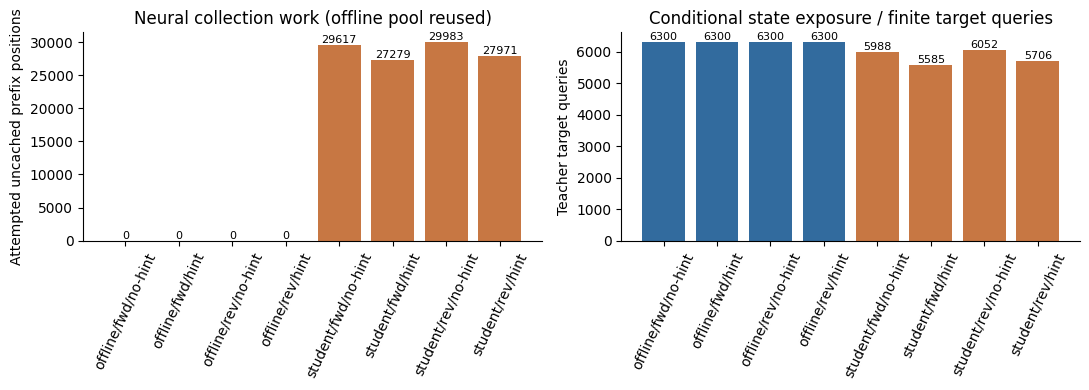

Measured campaign-body wall: 63.055 s; includes checkpoint hashes and fsynced journals.
Lifetime Linux RSS: 754740 KiB; MemAvailable observations: {'before': 123701740, 'after': 123588740}
Two observations are not a monitored available-memory minimum. Inner generation timers exclude hashing/journaling.


In [10]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
positions=[sum(next(a for a in c["arms"] if a["arm"]==name)["collection_cost"]["attempted_forward_positions"]
               for c in campaigns) for name in arm_names]
states=[sum(next(a for a in c["arms"] if a["arm"]==name)["teacher_target_queries"]
            for c in campaigns) for name in arm_names]
names=[name.replace("student-prefix","student").replace("forward","fwd").replace("reverse","rev") for name in arm_names]
for ax,values,title,ylabel in zip(axes,(positions,states),
    ("Neural collection work (offline pool reused)","Conditional state exposure / finite target queries"),
    ("Attempted uncached prefix positions","Teacher target queries")):
    ax.bar(range(8),values,color=[colors[name.split("/")[0]] for name in arm_names])
    ax.set(xticks=range(8),xticklabels=names,title=title,ylabel=ylabel)
    ax.tick_params(axis="x",labelrotation=65)
    for i,value in enumerate(values):ax.text(i,value,str(value),ha="center",va="bottom",fontsize=8)
plt.tight_layout();plt.show()
print("Measured campaign-body wall:",round(measured["wall_seconds"],3),"s; includes checkpoint hashes and fsynced journals.")
print("Lifetime Linux RSS:",measured["peak_process_rss_kib"],"KiB; MemAvailable observations:",measured["observed_mem_available_kib"])
print("Two observations are not a monitored available-memory minimum. Inner generation timers exclude hashing/journaling.")


## Evidence boundary

The source-bound campaign retains10,656 attempts:72 authored finite teacher draws and10,584 actual neural student responses. It includes720 optimizer updates,6,442 cap stops and no ordinary generation exceptions. Skipped-error and partial-work behavior are separately tested with scripted controls, not invented main-run failures.

The conditional gradients used here hold collected states fixed. They do not include the student state-occupancy derivative. Teacher context, prefix source, divergence direction and top-k coarsening are separate interventions; none alone is a complete named production algorithm. No teacher API, model download, GPU, model-scale inference, self-teacher, pretrained result, optimized memory saving or learner mastery is claimed.

Read the [frozen specification](../../experiments/specs/2026-10-04-student-prefix-distillation.md) and [actual report](../../experiments/reports/2026-10-04-student-prefix-distillation.md). The existing response-NLL and exact forward-KL/T² lessons remain unchanged. Animations remain proposals for separately authorized Mac production.